In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import linregress

In [2]:
nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")

fund = pd.read_csv("../data/processed/01_fund_master_cleaned.csv")

In [3]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [4]:
nav["date"] = pd.to_datetime(nav["date"])

In [5]:
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [6]:
nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


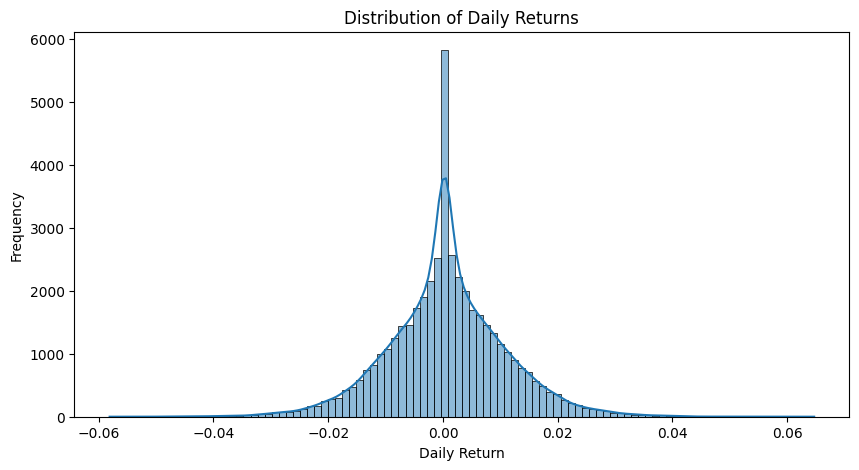

In [7]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=100,
    kde=True
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [10]:
plt.savefig("../reports/charts/chart16_daily_return_distribution.png",
            dpi=300,
            bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [9]:
plt.savefig("../reports/charts/chart16_daily_return_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

<Figure size 640x480 with 0 Axes>

In [11]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [12]:
def calculate_cagr(start_nav, end_nav, years):
    return ((end_nav / start_nav) ** (1 / years) - 1) * 100

In [13]:
cagr_data = []

for fund_code in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == fund_code].sort_values("date")

    if len(temp) < 2:
        continue

    start_nav = temp.iloc[0]["nav"]
    end_nav = temp.iloc[-1]["nav"]

    cagr_5yr = calculate_cagr(start_nav, end_nav, 5)
    cagr_3yr = calculate_cagr(start_nav, end_nav, 3)
    cagr_1yr = calculate_cagr(start_nav, end_nav, 1)

    cagr_data.append([
        fund_code,
        cagr_1yr,
        cagr_3yr,
        cagr_5yr
    ])

cagr_df = pd.DataFrame(
    cagr_data,
    columns=[
        "amfi_code",
        "CAGR_1Y",
        "CAGR_3Y",
        "CAGR_5Y"
    ]
)

In [14]:
cagr_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,12.133575,3.891151,2.316843
1,100025,21.155227,6.605772,3.912653
2,100033,218.514228,47.132838,26.074068
3,101206,153.456216,36.343461,20.442730
4,101207,39.949603,11.855469,6.953336


In [15]:
cagr_df = cagr_df.sort_values(
    "CAGR_5Y",
    ascending=False
)

cagr_df.head(10)

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
25,120505,248.684056,51.638925,28.376762
21,119598,244.043537,50.963214,28.033224
39,149324,242.490579,50.735731,27.917430
36,148569,238.658097,50.171374,27.629860
34,148567,227.781083,48.546114,26.799277
30,120843,227.047809,48.435261,26.742494
2,100033,218.514228,47.132838,26.074068
38,149323,212.717589,46.234812,25.611807
16,119094,198.464473,43.978468,24.445309
19,119551,174.560913,40.027361,22.384873


In [16]:
cagr_df.to_csv(
    "../reports/cagr_comparison.csv",
    index=False
)

In [17]:
risk_free_rate = 0.065

In [18]:
sharpe_list = []

for fund_code in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == fund_code]

    mean_return = temp["daily_return"].mean() * 252
    std_return = temp["daily_return"].std() * np.sqrt(252)

    if std_return == 0 or np.isnan(std_return):
        sharpe = np.nan
    else:
        sharpe = (mean_return - risk_free_rate) / std_return

    sharpe_list.append([fund_code, sharpe])

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=["amfi_code", "Sharpe_Ratio"]
)

In [19]:
sharpe_df = sharpe_df.sort_values(
    "Sharpe_Ratio",
    ascending=False
)

sharpe_df.head(10)

,amfi_code,Sharpe_Ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


In [20]:
sharpe_df.to_csv(
    "../reports/sharpe_ratio.csv",
    index=False
)

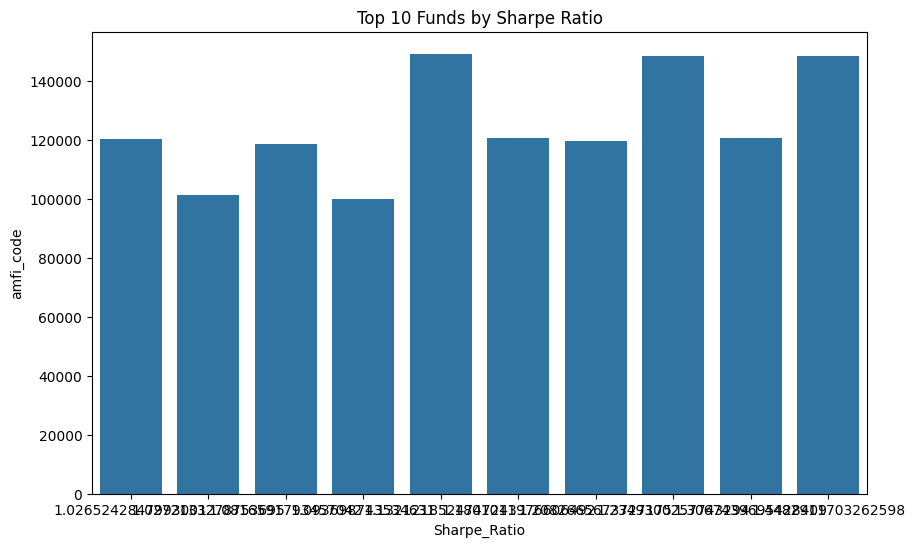

In [21]:
top10 = sharpe_df.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="Sharpe_Ratio",
    y="amfi_code"
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.savefig(
    "../reports/charts/chart17_sharpe_ratio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
sortino_list = []

for fund_code in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == fund_code]

    mean_return = temp["daily_return"].mean() * 252

    downside = temp[temp["daily_return"] < 0]["daily_return"]

    downside_std = downside.std() * np.sqrt(252)

    if downside_std == 0 or np.isnan(downside_std):
        sortino = np.nan
    else:
        sortino = (mean_return - risk_free_rate) / downside_std

    sortino_list.append([fund_code, sortino])

sortino_df = pd.DataFrame(
    sortino_list,
    columns=["amfi_code", "Sortino_Ratio"]
)

In [23]:
sortino_df = sortino_df.sort_values(
    "Sortino_Ratio",
    ascending=False
)

sortino_df.head(10)

,amfi_code,Sortino_Ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353
38,149323,1.875101
9,118632,1.850133
2,100033,1.829134
24,120504,1.805294
3,101206,1.799563


In [24]:
sortino_df.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

In [26]:
benchmark = pd.read_csv("../data/processed/10_benchmark_indices_cleaned.csv")

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [27]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='object')

In [28]:
benchmark = pd.read_csv("../data/processed/10_benchmark_indices_cleaned.csv")

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [29]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='object')

In [30]:
benchmark = pd.read_csv("../data/processed/10_benchmark_indices_cleaned.csv")
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [31]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='object')

In [32]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [33]:
alpha_beta = []

for fund_code in nav["amfi_code"].unique():

    fund_data = nav[nav["amfi_code"] == fund_code][["date","daily_return"]]

    merged = pd.merge(
        fund_data,
        nifty100[["date","benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    if len(merged) < 30:
        continue

    slope, intercept, r, p, stderr = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha = intercept * 252
    beta = slope

    alpha_beta.append([
        fund_code,
        alpha,
        beta
    ])

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "Alpha",
        "Beta"
    ]
)

In [34]:
alpha_beta_df.head()

,amfi_code,Alpha,Beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [35]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

In [36]:
drawdown = []

for fund_code in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == fund_code].copy()

    temp["running_max"] = temp["nav"].cummax()

    temp["drawdown"] = (
        temp["nav"] /
        temp["running_max"]
        - 1
    )

    worst = temp["drawdown"].min()

    drawdown.append([
        fund_code,
        worst
    ])

drawdown_df = pd.DataFrame(
    drawdown,
    columns=[
        "amfi_code",
        "Maximum_Drawdown"
    ]
)

In [37]:
drawdown_df.sort_values(
    "Maximum_Drawdown"
).head()

,amfi_code,Maximum_Drawdown
22,119599,-0.525742
17,119095,-0.516778
4,101207,-0.354469
39,149324,-0.311719
21,119598,-0.287060


In [38]:
drawdown_df.to_csv(
    "../reports/max_drawdown.csv",
    index=False
)

In [39]:
scorecard = cagr_df.merge(
    sharpe_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    fund[["amfi_code", "expense_ratio_pct"]],
    on="amfi_code"
)

scorecard.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe_Ratio,Alpha,Beta,Maximum_Drawdown,expense_ratio_pct
0,120505,248.684056,51.638925,28.376762,1.180101,0.292636,0.000549,-0.181885,1.36
1,119598,244.043537,50.963214,28.033224,0.945308,0.303370,-0.023196,-0.287060,1.43
2,149324,242.490579,50.735731,27.917430,0.949796,0.300579,0.011455,-0.311719,1.52
3,148569,238.658097,50.171374,27.629860,1.234930,0.282704,0.018134,-0.163967,1.60
4,148567,227.781083,48.546114,26.799277,1.448291,0.269838,0.023684,-0.112657,1.46


In [40]:
scorecard["return_rank"] = scorecard["CAGR_3Y"].rank(ascending=False)

scorecard["sharpe_rank"] = scorecard["Sharpe_Ratio"].rank(ascending=False)

scorecard["alpha_rank"] = scorecard["Alpha"].rank(ascending=False)

scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(ascending=True)

scorecard["drawdown_rank"] = scorecard["Maximum_Drawdown"].rank(ascending=False)

In [41]:
scorecard["Fund_Score"] = (
    scorecard["return_rank"] * 0.30 +
    scorecard["sharpe_rank"] * 0.25 +
    scorecard["alpha_rank"] * 0.20 +
    scorecard["expense_rank"] * 0.15 +
    scorecard["drawdown_rank"] * 0.10
)

scorecard["Fund_Score"] = (
    100 -
    (
        scorecard["Fund_Score"] /
        scorecard["Fund_Score"].max()
    ) * 100
)

In [42]:
scorecard = scorecard.sort_values(
    "Fund_Score",
    ascending=False
)

scorecard.head(10)

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe_Ratio,Alpha,Beta,Maximum_Drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,Fund_Score
0,120505,248.684056,51.638925,28.376762,1.180101,0.292636,0.000549,-0.181885,1.36,1.0,5.0,3.0,15.0,25.0,80.926054
4,148567,227.781083,48.546114,26.799277,1.448291,0.269838,0.023684,-0.112657,1.46,5.0,1.0,7.0,23.0,8.0,79.543884
5,120843,227.047809,48.435261,26.742494,1.306744,0.273305,-0.022830,-0.129740,1.45,6.0,2.0,5.0,22.0,13.0,78.161714
6,100033,218.514228,47.132838,26.074068,1.093699,0.271954,0.005104,-0.162172,1.38,7.0,7.0,6.0,17.0,20.0,73.462336
3,148569,238.658097,50.171374,27.629860,1.234930,0.282704,0.018134,-0.163967,1.60,4.0,3.0,4.0,36.5,21.0,71.458189
1,119598,244.043537,50.963214,28.033224,0.945308,0.303370,-0.023196,-0.287060,1.43,2.0,14.0,1.0,21.0,36.0,69.454043
12,120504,151.267885,35.949932,20.234028,1.026524,0.211948,0.016232,-0.125883,0.80,13.0,10.0,13.0,12.0,12.0,66.827920
14,119552,135.772732,33.095853,18.713119,0.953279,0.198686,-0.026159,-0.118035,0.66,15.0,12.0,15.0,4.0,11.0,66.275052
2,149324,242.490579,50.735731,27.917430,0.949796,0.300579,0.011455,-0.311719,1.52,3.0,13.0,2.0,26.5,37.0,66.205943
9,119551,174.560913,40.027361,22.384873,1.208267,0.232010,-0.031751,-0.150124,1.54,10.0,4.0,10.0,30.5,17.0,66.067726


In [43]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

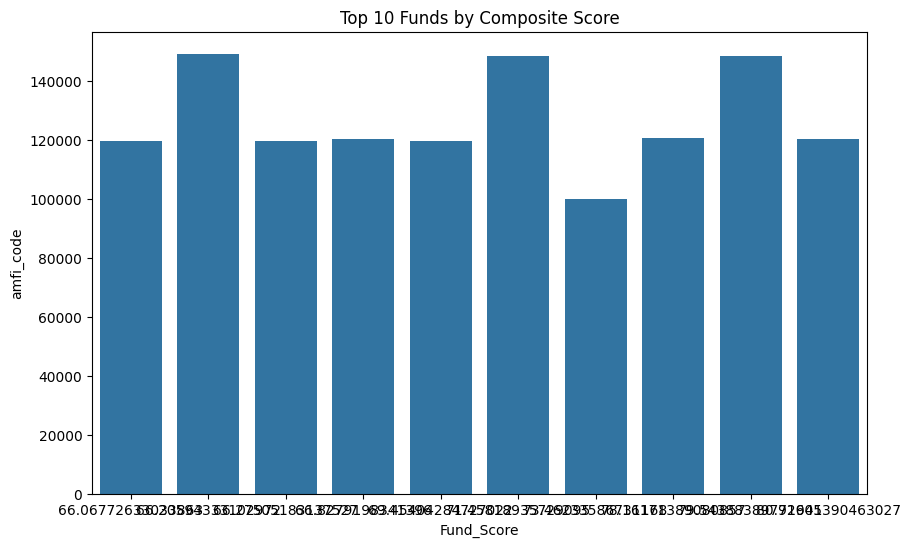

In [44]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=scorecard.head(10),
    x="Fund_Score",
    y="amfi_code"
)

plt.title("Top 10 Funds by Composite Score")

plt.savefig(
    "../reports/charts/chart19_fund_scorecard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [45]:
top5 = scorecard.head(5)["amfi_code"].tolist()

top5

[120505, 148567, 120843, 100033, 148569]

In [46]:
top5_nav = nav[
    nav["amfi_code"].isin(top5)
][["date","amfi_code","nav"]]

In [47]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

bench = benchmark[
    benchmark["index_name"].isin(["NIFTY50","NIFTY100"])
]

In [48]:
import plotly.graph_objects as go

fig = go.Figure()

# Top 5 Funds
for fund_code in top5:

    temp = top5_nav[top5_nav["amfi_code"] == fund_code]

    fig.add_trace(
        go.Scatter(
            x=temp["date"],
            y=temp["nav"],
            mode="lines",
            name=f"Fund {fund_code}"
        )
    )

# Benchmarks
for idx in ["NIFTY50","NIFTY100"]:

    temp = bench[
        bench["index_name"] == idx
    ]

    fig.add_trace(
        go.Scatter(
            x=temp["date"],
            y=temp["close_value"],
            mode="lines",
            name=idx,
            line=dict(width=4)
        )
    )

fig.update_layout(
    title="Top 5 Funds vs NIFTY50 & NIFTY100",
    xaxis_title="Date",
    yaxis_title="NAV / Index Value"
)

fig.show()

In [49]:
fig.write_image(
    "../reports/charts/benchmark_comparison.png"
)

In [50]:
tracking_error = []

for fund_code in top5:

    fund_returns = nav[
        nav["amfi_code"] == fund_code
    ][["date","daily_return"]]

    benchmark_returns = nifty100[
        ["date","benchmark_return"]
    ]

    merged = pd.merge(
        fund_returns,
        benchmark_returns,
        on="date"
    ).dropna()

    te = (
        (
            merged["daily_return"] -
            merged["benchmark_return"]
        ).std()
        * np.sqrt(252)
    )

    tracking_error.append(
        [fund_code, te]
    )

tracking_error_df = pd.DataFrame(
    tracking_error,
    columns=[
        "amfi_code",
        "Tracking_Error"
    ]
)

tracking_error_df

,amfi_code,Tracking_Error
0,120505,0.231968
1,148567,0.189664
2,120843,0.206425
3,100033,0.228699
4,148569,0.217365


In [51]:
tracking_error_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)